In [20]:
from pickle import load
import pandas as pd
from sklearn.model_selection import train_test_split
import shap
import numpy as np

In [2]:
pipe_path = "../model/20251021-15h51m49_rf.pkl"
data_path = "../data/clean/dvf.csv"

In [3]:
def load_pipeline(pipe_path):
    with open(pipe_path, "rb") as f:
        return load(f)

In [4]:
def load_df(data_path):
    return pd.read_csv(data_path, low_memory=False, nrows=10000)

In [5]:
pipe = load_pipeline(pipe_path)

In [6]:
df = load_df(data_path)

In [7]:
def generate_Xy(df:pd.DataFrame):
    y = df['Valeur fonciere']
    X = df.drop(columns=['Valeur fonciere', 'Code departement'])
    return X,y

In [8]:
def generate_train_test(X, y, test_size, random_state):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

In [9]:
X, y = generate_Xy(df)
X_train, X_test, y_train, y_test = generate_train_test(X, y, test_size=0.3, random_state=8)

In [10]:
# Get scaled data
X_test_scaled = pipe.named_steps['scaler'].transform(X_test)

In [11]:
# SHAP analysis
explainer = shap.TreeExplainer(pipe.named_steps['rf'])
shap_values = explainer.shap_values(X_test_scaled)

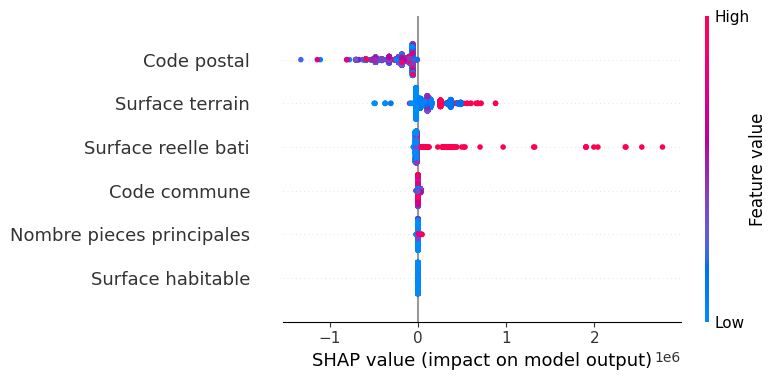

In [12]:
# Visualizations
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

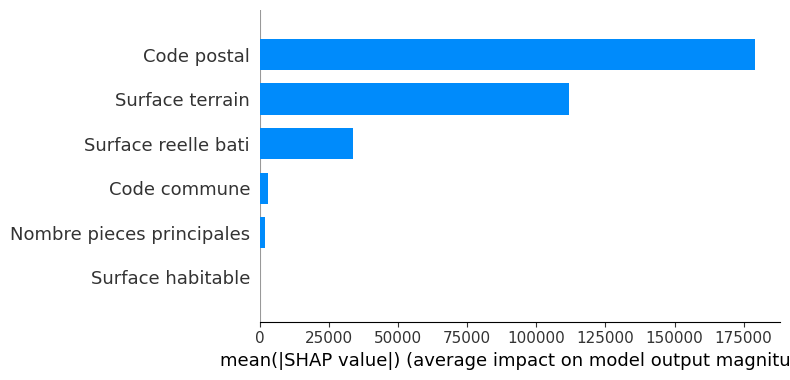

In [13]:
# Feature importance plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar")

In [14]:
# Individual prediction explanation
shap.force_plot(explainer.expected_value, shap_values[0], X_test_scaled[0], 
                feature_names=X.columns)

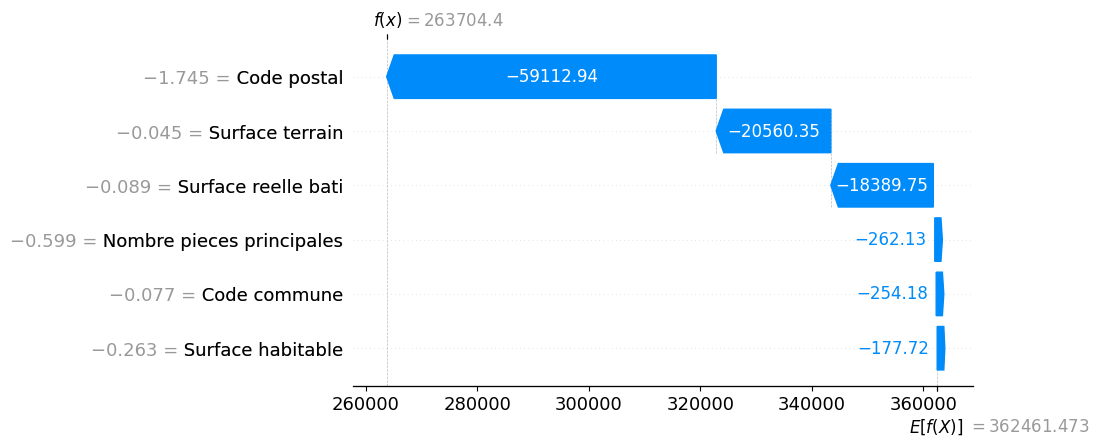

In [15]:
# Waterfall plot for single prediction
shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                       base_values=explainer.expected_value,
                                       data=X_test_scaled[0],
                                       feature_names=X.columns))

In [23]:
rs = np.random.RandomState(0)
df = pd.DataFrame(X_test_scaled)
df.columns = X_test.columns
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Code postal,Code commune,Surface habitable,Nombre pieces principales,Surface reelle bati,Surface terrain
Code postal,1.000000,0.220739,-0.098365,-0.005556,0.016339,0.038674
Code commune,0.220739,1.000000,-0.062277,0.010471,0.023900,0.036694
Surface habitable,-0.098365,-0.062277,1.000000,0.193384,0.072972,-0.097213
Nombre pieces principales,-0.005556,0.010471,0.193384,1.000000,0.232598,-0.111254
Surface reelle bati,0.016339,0.023900,0.072972,0.232598,1.000000,-0.037290
Surface terrain,0.038674,0.036694,-0.097213,-0.111254,-0.037290,1.000000
